## Data Ingestion

### Importing required modules and libraries

In [12]:
# I/O & Visualization
import pandas as pd
import numpy as np
import seaborn as sns
import plotly.express as px
import matplotlib.pyplot as plt
import itables
import io
import os
from dotenv import load_dotenv
from supabase import create_client


# Pre-processing 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Handle imbalance data
from imblearn.over_sampling import SMOTE

# Models
from sklearn.linear_model import LogisticRegression 
from sklearn.ensemble import RandomForestClassifier 
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

# Evaluation
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

# Seaborn professional style
sns.set_style("whitegrid")

### Importing the CSV dataset

In [13]:
# Load variables from .env file into environment
load_dotenv()

url = os.environ.get("sup_url")
key = os.environ.get("sup_key")

supabase = create_client(url, key)

response = supabase.table("airline_fraud_data").select("*").csv().execute()
df_raw = pd.read_csv(io.StringIO(response.data))

### Previewing the dataset

In [14]:
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   transaction_date    1000 non-null   str    
 1   payment_id          1000 non-null   str    
 2   mrn                 1000 non-null   str    
 3   pnr                 1000 non-null   str    
 4   email_address       1000 non-null   str    
 5   ip_address          1000 non-null   str    
 6   device_id           1000 non-null   str    
 7   route               1000 non-null   str    
 8   amount              1000 non-null   float64
 9   currency            1000 non-null   str    
 10  card_type           1000 non-null   str    
 11  card_bin            1000 non-null   int64  
 12  card_last_4         1000 non-null   int64  
 13  bank_name           1000 non-null   str    
 14  bin_country         1000 non-null   str    
 15  loyalty_tier        272 non-null    str    
 16  txn_origin_country

In [15]:
# Making a copy of the original raw dataset
df = df_raw.copy()

## Data Cleaning & Preprocessing

In [16]:
# Converting card_last_4 to dtype 'str' as we have 0 values at the start which otherwise wouldn't reflect if dtype is 'int'
df_copy['card_last_4'] = df_copy['card_last_4'].astype(str).str.zfill(4)

NameError: name 'df_copy' is not defined

In [ ]:
# Handling Missing Values in loyalty_tier column
df['loyalty_tier'] = df['loyalty_tier'].fillna('None')

In [ ]:
# Converting the 'transaction_date' column data type to datetime
df['transaction_date'] = pd.to_datetime(df['transaction_date'])

In [ ]:
print(df.head(5))

     transaction_date          payment_id           mrn     pnr  \
0 2025-01-01 00:00:46  02XCWOFKVZUYNKIYAT  02XCWOFKVZUY  02XCWO   
1 2025-01-01 00:00:48  FQ96IXUSPHNEQNQG29  FQ96IXUSPHNE  FQ96IX   
2 2025-01-01 00:00:48  M5J6WTJ8G5YGB3A7DE  M5J6WTJ8G5YG  M5J6WT   
3 2025-01-01 00:03:06  IRD5PU5Y7SOT0FUBOF  IRD5PU5Y7SOT  IRD5PU   
4 2025-01-01 00:03:24  KAFWWIC7IAIJH1VJZY  KAFWWIC7IAIJ  KAFWWI   

                       email_address       ip_address  \
0             iek8i70tqgf@icloud.com  205.153.250.110   
1  k0oaoqyjs8r@aeroline-partners.com  217.193.114.197   
2          hunfvk3z3x@protonmail.com   171.120.149.95   
3                   4bt7dj@gmail.com     73.123.66.31   
4              64c7nt@protonmail.com     96.236.46.86   

                          device_id    route  amount currency   card_type  \
0  933d2470bebe86d7e174358abf046986  LHR-JFK  110.26      USD        Visa   
1  9b2f0651d98494834ec172c49231cb0f  JFK-LHR  228.65      BRL        Visa   
2  d1bd71faf7c0f5010dfe

## Exploratory Data Analysis

In [ ]:
# Checking the ratio of fraud vs non-fraud distribution
df.is_fraud.value_counts(normalize=True)*100

is_fraud
0    98.509533
1     1.490467
Name: proportion, dtype: float64

The dataset has an overall fraud rate of 1.49%

In [ ]:
# Define exchange rates relative to 1 USD (Updated exchange rates relative to 1 USD (June 2026))
exchange_rates = {
    'USD': 1.00,
    'GBP': 0.76,
    'EUR': 0.88,
    'INR': 94.67,
    'AED': 3.67,
    'SGD': 1.30,
    'AUD': 1.45,
    'CNY': 6.78,
    'QAR': 3.64,
    'CAD': 1.42,
    'JPY': 161.76,
    'BRL': 5.20,
    'ZAR': 16.61,
    'TRY': 46.49,
    'HKD': 7.80,
    'KRW': 1546.43
}

# Map exchange rates and calculate a standardized USD amount
# We divide the native amount by the currency's rate to normalize it to USD
df['fx_rate'] = df['currency'].map(exchange_rates)
df['amount_usd'] = df['amount'] / df['fx_rate']

Downsampling the data to avoid kernal crash as aggregating the 'amount' column is very resource intensive 

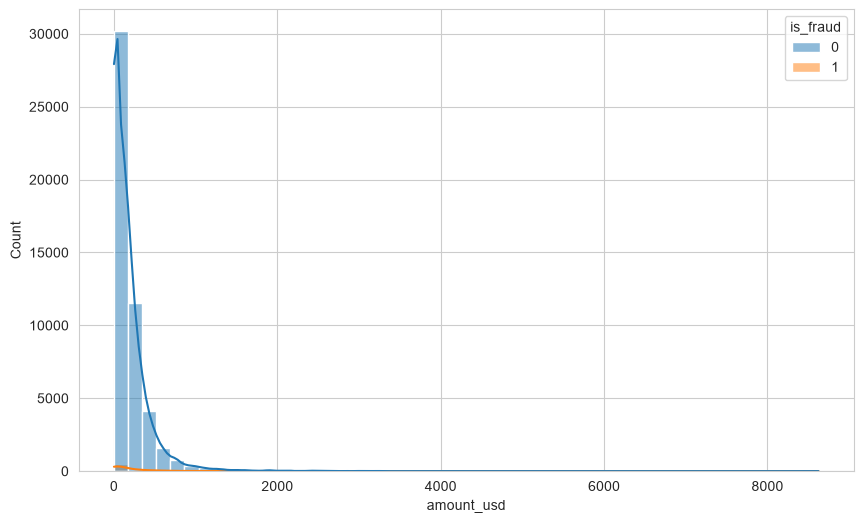

In [ ]:
# Strategic Downsampling
# Taking a random sample of 50,000 rows to protect system memory or avoid kernal crash
df_sample = df.sample(n=50000, random_state=22)

# Plotting the cleaned, normalized distribution
plt.figure(figsize=(10,6))

sns.histplot(
    data=df_sample, 
    x='amount_usd',
    hue='is_fraud', 
    kde=True, 
    bins=50
)

plt.show()

### Calculating actual revenue loss after normalizing the currencies

In [ ]:
total_txn_amt = df['amount_usd'].sum()
print(f"Sum of total transaction amount in USD: {total_txn_amt:,.2f}")
fraud_total_amt = df.query("is_fraud == 1")['amount'].sum()
print(f"Sum of total fraud amount in USD: {fraud_total_amt:,.2f}")

fraud_perc_amt = fraud_total_amt * 100 / total_txn_amt
print(f"Percentage of revenue loss: {fraud_perc_amt:,.2f}%")

Sum of total transaction amount in USD: 578,806,359.97
Sum of total fraud amount in USD: 16,238,750.51
Percentage of revenue loss: 2.81%


### Categorical Risk Profiles

In [ ]:
# Aggregate the counts and sums
risk_profile = df.groupby(['card_type', 'bin_country', 'bank_name']).agg(
    total_transactions=('is_fraud', 'count'),    # Total number of rows
    fraud_transactions=('is_fraud', 'sum')       # Total number of 1s
).reset_index()

# Calculate the fraud rate manually
risk_profile['fraud_rate'] = (risk_profile['fraud_transactions'] / risk_profile['total_transactions']).round(3)

# Sort to find the most dangerous combinations at the top
risk_profile = risk_profile.sort_values(by='fraud_rate', ascending=False)

# Let's peek at the top 10 riskiest combinations
print(risk_profile.head(10))

      card_type bin_country            bank_name  total_transactions  \
2   Diners Club          US     Diners Club Intl               27792   
12        RuPay          IN  State Bank of India               83070   
18         Visa          IN           ICICI Bank              125630   
1          Amex          US     American Express              167237   
7    MasterCard          FR          BNP Paribas               97474   
6    MasterCard          DE        Deutsche Bank              111594   
3      Discover          US   Discover Financial               83236   
4    MasterCard          AE         Emirates NBD               55272   
20         Visa          SG             DBS Bank               69185   
22         Visa          US                Chase              389158   

    fraud_transactions  fraud_rate  
2                  446       0.016  
12                1311       0.016  
18                1962       0.016  
1                 2456       0.015  
7                 1501

In [ ]:
# Extracting the hour from date column
df['transaction_hour'] = df['transaction_date'].dt.hour

### Checking for fraud spikes during odd hours

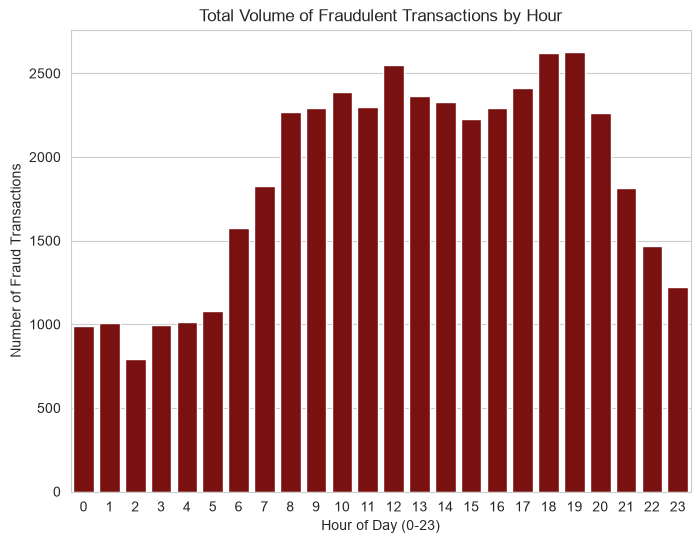

In [ ]:
plt.figure(figsize=(8,6))

fraud_txns = df[df['is_fraud'] == 1]

sns.countplot(
    x='transaction_hour',
    data=fraud_txns,
    color='darkred'
)

plt.title('Total Volume of Fraudulent Transactions by Hour')
plt.xlabel('Hour of Day (0-23)')
plt.ylabel('Number of Fraud Transactions')
plt.show()

Observation: No unusual spikes are visible during odd or midnight hours

## Feature Engineering

In [ ]:
df_copy = df.copy()

In [ ]:
itables.show(df_copy)

Loading ITables v2.8.1 from the internet... (need help?)
